
# Q-Learning for a 5×5 Grid Maze
### Student notebook version

This notebook is designed to go **with your video**.  
The goal is simple: after watching the animation, you can come here and run the algorithm **one step at a time**.

You will be able to:
- start an episode from the top-left corner
- take one Q-learning update at a time
- inspect the exact transition `(s, a, r, s')`
- see how one Q-value changes after each step
- watch the greedy arrows slowly become a policy
- run the same training schedule used in the video
- check the final greedy path to the goal

---
### Learning goals

By the end of this notebook, you should be able to explain:

1. what `Q(s,a)` means  
2. how the Q-learning update uses `reward + gamma * max(Q(next_state))`  
3. the difference between **explore** and **exploit**  
4. why the arrows in the grid slowly become more organized  
5. how training episodes and the final greedy demo are different



## Environment summary

This notebook follows the same environment as the video:

- **Grid:** 5 × 5
- **Start:** top-left `(0,0)`
- **Goal:** bottom-right `(4,4)`, reward `+1.0`, **terminal**
- **Trap:** reward `-1.0`, but **not terminal**
- **Mud:** reward `-0.5`
- **Normal step:** reward `-0.04`
- **Wall hit:** reward `-0.1`, and the agent stays in place

### Training schedule from the video

- **Episodes 1–5:** visual training, `max_steps = 30`, `epsilon` starts at `0.30` and decays by `×0.85`
- **Episodes 6–24:** fast training, `max_steps = 50`, `epsilon = 0.05`
- **Episode 25:** final greedy demo, `max_steps = 12`, no learning

### Q-learning rule

\[
Q(s,a) \leftarrow Q(s,a) + lpha \Big[r + \gamma \max_{a'}Q(s',a') - Q(s,a)\Big]
\]

In this notebook:
- `alpha = 0.5`
- `gamma = 0.9`
- `seed = 42`


In [1]:

%matplotlib inline
import pandas as pd


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from matplotlib.patches import Rectangle, FancyArrowPatch

class QLearningExplorer:
    """
    Student-facing explorer for the Q-learning video.

    Key design choices copied from the Manim demo:
    - 5x5 grid
    - alpha = 0.5
    - gamma = 0.9
    - epsilon starts at 0.30
    - Goal (+1.0) is terminal
    - Trap (-1.0) is NOT terminal; it is a normal transition with a big negative reward
    - Mud = -0.5
    - Normal step = -0.04
    - Wall hit = -0.1 and the agent stays in place
    - Episodes 1-5: visual / slow, max 30 steps, epsilon decays by x0.85 each episode
    - Episodes 6-24: backend / fast, max 50 steps, epsilon fixed at 0.05
    - Episode 25: final greedy demo, max 12 steps, no learning
    """

    ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    ACTION_NAMES = ["UP", "DOWN", "LEFT", "RIGHT"]
    ACTION_ARROWS = {0: "↑", 1: "↓", 2: "←", 3: "→"}
    ACTION_TO_DELTA = {
        0: (0.00, -0.28),
        1: (0.00,  0.28),
        2: (-0.28, 0.00),
        3: (0.28,  0.00),
    }
    CELL_COLORS = {
        "goal": "#147d75",
        "trap": "#8c1d1d",
        "mud":  "#f06a00",
        "step": "#3d4a5f",
    }

    def __init__(self, alpha=0.5, gamma=0.9, epsilon=0.3, seed=42):
        self.alpha = float(alpha)
        self.gamma = float(gamma)
        self.epsilon0 = float(epsilon)
        self.seed = int(seed)

        self.grid_size = 5
        self.start_state = (0, 0)
        self.goal_state = (4, 4)
        self.optimal_steps = 8

        self.rewards = np.array([
            [-0.04, -0.04, -0.04, -0.50, -1.00],
            [-0.04, -1.00, -0.04, -1.00, -1.00],
            [-0.04, -0.50, -0.04, -0.04, -0.04],
            [-1.00, -1.00, -1.00, -1.00, -0.04],
            [-1.00, -0.04, -0.04, -0.04,  1.00],
        ], dtype=float)

        self.reset(seed=seed)

    # ----------------------------
    # Core state management
    # ----------------------------
    def reset(self, seed=None):
        if seed is not None:
            self.seed = int(seed)

        self.rng = np.random.default_rng(self.seed)
        random.seed(self.seed)

        self.q_table = np.zeros((self.grid_size, self.grid_size, 4), dtype=float)

        # In the video, initial displayed arrows point RIGHT.
        self.arrow_directions = {
            (r, c): 3
            for r in range(self.grid_size)
            for c in range(self.grid_size)
            if (r, c) != self.goal_state
        }

        self.steps_hist = []
        self.returns_hist = []
        self.episode_summaries = []
        self.step_logs = []

        self.current_episode = 0
        self.current_step = 0
        self.current_return = 0.0
        self.current_state = self.start_state
        self.current_path = [self.start_state]
        self.current_epsilon = self.epsilon0
        self.in_episode = False
        self.final_demo = False
        self.done = False
        self.max_steps_current = None
        self.last_step_info = None

        print(f"Reset complete. Seed = {self.seed}. Q-table is all zeros.")

    def state_label(self, state):
        return f"r{state[0]}, c{state[1]}"

    def moving_avg(self, values, window=5):
        if not values:
            return []
        out = []
        for i in range(len(values)):
            start = max(0, i - window + 1)
            out.append(float(np.mean(values[start:i + 1])))
        return out

    def cell_kind(self, r, c):
        val = self.rewards[r, c]
        if np.isclose(val, 1.0):
            return "goal"
        if np.isclose(val, -1.0):
            return "trap"
        if np.isclose(val, -0.5):
            return "mud"
        return "step"

    # ----------------------------
    # Policy display helpers
    # ----------------------------
    def greedy_for_display(self, qvals, prefer_action_idx=None):
        max_val = float(np.max(qvals))
        best = np.flatnonzero(np.isclose(qvals, max_val))
        if len(best) == 1:
            return int(best[0])
        if prefer_action_idx is not None and prefer_action_idx in best:
            return int(prefer_action_idx)
        return int(self.rng.choice(best))

    def best_action_det(self, r, c):
        """
        Greedy action with tie-breaking that prefers the arrow currently shown on screen.
        This matches the spirit of the Manim demo.
        """
        q = self.q_table[r, c]
        max_val = float(np.max(q))
        best = np.flatnonzero(np.isclose(q, max_val))

        saved_act = self.arrow_directions.get((r, c), None)
        if saved_act is not None and saved_act in best:
            return int(saved_act)

        return int(self.rng.choice(best))

    def refresh_policy_from_q(self):
        """
        Recompute the displayed greedy arrow in every non-goal cell.
        """
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                if (r, c) == self.goal_state:
                    continue
                saved = self.arrow_directions.get((r, c), 3)
                self.arrow_directions[(r, c)] = self.greedy_for_display(
                    self.q_table[r, c],
                    prefer_action_idx=saved
                )

    # ----------------------------
    # Environment dynamics
    # ----------------------------
    def get_step_result(self, curr_pos, action_idx):
        r, c = curr_pos
        di, dj = self.ACTIONS[action_idx]
        nr, nc = r + di, c + dj

        if 0 <= nr < self.grid_size and 0 <= nc < self.grid_size:
            reward = float(self.rewards[nr, nc])
            next_pos = (nr, nc)
            hit_wall = False
        else:
            reward = -0.1
            next_pos = curr_pos
            hit_wall = True

        return next_pos, reward, hit_wall

    # ----------------------------
    # Episode control
    # ----------------------------
    def begin_episode(self, episode=None, max_steps=30, epsilon=None, final_demo=False):
        if episode is None:
            episode = self.current_episode + 1

        self.current_episode = int(episode)
        self.current_step = 0
        self.current_return = 0.0
        self.current_state = self.start_state
        self.current_path = [self.start_state]
        self.in_episode = True
        self.final_demo = bool(final_demo)
        self.done = False
        self.max_steps_current = int(max_steps)

        if epsilon is not None:
            self.current_epsilon = float(epsilon)
        elif final_demo:
            self.current_epsilon = 0.0

        self.last_step_info = None

        print(
            f"Started episode {self.current_episode} | "
            f"epsilon = {self.current_epsilon:.3f} | "
            f"max_steps = {self.max_steps_current} | "
            f"final_demo = {self.final_demo}"
        )

    def step_episode(self, verbose=True):
        if not self.in_episode or self.done:
            raise RuntimeError("Start an episode first with begin_episode(...).")

        r, c = self.current_state
        greedy_idx = self.best_action_det(r, c)

        if self.final_demo:
            action_idx = greedy_idx
            is_exploring = False
        else:
            if self.rng.random() < self.current_epsilon:
                action_idx = int(self.rng.integers(4))
                is_exploring = True
            else:
                action_idx = greedy_idx
                is_exploring = False

        next_pos, reward, hit_wall = self.get_step_result(self.current_state, action_idx)

        old_q = float(self.q_table[r, c, action_idx])
        max_next_q = float(np.max(self.q_table[next_pos[0], next_pos[1]]))
        reached_goal = (next_pos == self.goal_state and next_pos != self.current_state)

        if reached_goal:
            max_next_q = 0.0

        target = reward + self.gamma * max_next_q
        td_error = target - old_q

        if self.final_demo:
            new_q = old_q
        else:
            new_q = old_q + self.alpha * td_error
            self.q_table[r, c, action_idx] = new_q

            qvals = self.q_table[r, c]
            best_act_idx = self.greedy_for_display(qvals, prefer_action_idx=action_idx)
            self.arrow_directions[(r, c)] = best_act_idx

        self.current_state = next_pos
        self.current_step += 1
        self.current_return += float(reward)
        self.current_path.append(next_pos)

        self.done = reached_goal or (self.current_step >= self.max_steps_current)

        termination_reason = None
        if reached_goal:
            termination_reason = "goal"
        elif self.current_step >= self.max_steps_current:
            termination_reason = "max_steps"

        info = {
            "episode": self.current_episode,
            "step": self.current_step,
            "state": (r, c),
            "greedy_action": self.ACTION_NAMES[greedy_idx],
            "action_idx": action_idx,
            "action": self.ACTION_NAMES[action_idx],
            "decision": "explore" if is_exploring else "exploit",
            "next_state": next_pos,
            "reward": round(float(reward), 3),
            "hit_wall": hit_wall,
            "reached_goal": reached_goal,
            "old_q": round(float(old_q), 4),
            "target": round(float(target), 4),
            "td_error": round(float(td_error), 4),
            "new_q": round(float(new_q), 4),
            "episode_return_so_far": round(float(self.current_return), 4),
            "done": self.done,
            "termination_reason": termination_reason,
        }

        self.last_step_info = info
        self.step_logs.append(info)

        if verbose:
            print(
                f"Ep {self.current_episode} | step {self.current_step}: "
                f"{self.state_label((r, c))} --{self.ACTION_NAMES[action_idx]}--> "
                f"{self.state_label(next_pos)} | reward = {reward:+.2f} | "
                f"{info['decision']}"
            )

            if not self.final_demo:
                print(
                    f"Q update: old = {old_q:.4f}, "
                    f"target = {target:.4f}, "
                    f"td_error = {td_error:.4f}, "
                    f"new = {new_q:.4f}"
                )

            if hit_wall:
                print("Hit a wall, so the agent stayed in the same cell.")

            if reached_goal:
                print("Reached the goal. Episode finished.")
            elif self.done:
                print("Reached the step limit for this episode.")

        if self.done:
            self.finish_episode()

        return info

    def finish_episode(self):
        if not self.in_episode:
            return

        if not self.final_demo:
            self.steps_hist.append(self.current_step)
            self.returns_hist.append(self.current_return)
            self.episode_summaries.append({
                "episode": self.current_episode,
                "steps": self.current_step,
                "return": round(float(self.current_return), 4),
                "epsilon": round(float(self.current_epsilon), 4),
            })

        self.in_episode = False

    def step_and_render(self, title=None, figsize=(14, 6)):
        info = self.step_episode(verbose=True)

        if title is None:
            title = f"Episode {self.current_episode} after step {self.current_step}"

        self.render(title=title, figsize=figsize)
        return pd.DataFrame([info])

    def run_episode(self, max_steps=None, epsilon=None, final_demo=False, render_each=False):
        if max_steps is None:
            max_steps = self.max_steps_current or (12 if final_demo else 30)

        if not self.in_episode or self.done:
            self.begin_episode(
                episode=self.current_episode + 1,
                max_steps=max_steps,
                epsilon=epsilon,
                final_demo=final_demo,
            )

        logs = []
        while self.in_episode and not self.done:
            info = self.step_episode(verbose=False)
            logs.append(info)
            if render_each:
                self.render(title=f"Episode {self.current_episode} after step {self.current_step}")

        if logs:
            print(
                f"Episode {self.current_episode} finished in "
                f"{self.current_step} step(s) with return {self.current_return:.2f}."
            )
        else:
            print("No step was run.")

        return pd.DataFrame(logs)

    # ----------------------------
    # Video schedule helpers
    # ----------------------------
    def run_visual_schedule(self):
        rows = []
        eps = self.epsilon0

        for ep in range(1, 6):
            self.begin_episode(episode=ep, max_steps=30, epsilon=eps, final_demo=False)
            self.run_episode(max_steps=30, epsilon=eps, final_demo=False, render_each=False)

            rows.append({
                "episode": ep,
                "steps": self.current_step,
                "return": round(float(self.current_return), 4),
                "epsilon_used": round(float(eps), 4),
            })

            eps = max(0.05, eps * 0.85)
            self.current_epsilon = eps

        return pd.DataFrame(rows)

    def run_backend_schedule(self):
        self.current_epsilon = 0.05
        rows = []

        for ep in range(6, 25):
            self.begin_episode(episode=ep, max_steps=50, epsilon=0.05, final_demo=False)
            self.run_episode(max_steps=50, epsilon=0.05, final_demo=False, render_each=False)
            rows.append({
                "episode": ep,
                "steps": self.current_step,
                "return": round(float(self.current_return), 4),
            })

        self.refresh_policy_from_q()
        return pd.DataFrame(rows)

    def run_final_demo(self, max_steps=12):
        self.begin_episode(episode=25, max_steps=max_steps, epsilon=0.0, final_demo=True)
        logs = []

        while self.in_episode and not self.done:
            logs.append(self.step_episode(verbose=False))

        if logs:
            print(
                f"Final greedy demo ended after {self.current_step} step(s). "
                f"Termination: {self.last_step_info['termination_reason']}."
            )

        return pd.DataFrame(logs)

    # ----------------------------
    # Tables for learning
    # ----------------------------
    def values_table(self):
        arr = np.max(self.q_table, axis=2)
        idx = [f"r{r}" for r in range(self.grid_size)]
        cols = [f"c{c}" for c in range(self.grid_size)]
        return pd.DataFrame(np.round(arr, 3), index=idx, columns=cols)

    def policy_table(self):
        data = []
        for r in range(self.grid_size):
            row = []
            for c in range(self.grid_size):
                if (r, c) == self.goal_state:
                    row.append("GOAL")
                else:
                    act = self.arrow_directions.get(
                        (r, c),
                        self.greedy_for_display(self.q_table[r, c], prefer_action_idx=3)
                    )
                    row.append(self.ACTION_ARROWS[act])
            data.append(row)

        return pd.DataFrame(
            data,
            index=[f"r{r}" for r in range(self.grid_size)],
            columns=[f"c{c}" for c in range(self.grid_size)],
        )

    def q_table_for_state(self, state):
        r, c = state
        rows = []

        for a_idx in range(4):
            next_state, reward, hit_wall = self.get_step_result(state, a_idx)
            rows.append({
                "action": self.ACTION_NAMES[a_idx],
                "arrow": self.ACTION_ARROWS[a_idx],
                "q_value": round(float(self.q_table[r, c, a_idx]), 4),
                "next_state": next_state,
                "reward": reward,
                "hit_wall": hit_wall,
            })

        df = pd.DataFrame(rows)
        return df.sort_values("q_value", ascending=False, kind="stable").reset_index(drop=True)

    def inspect_state(self, state):
        df = self.q_table_for_state(state)
        best = df.iloc[0]

        print(f"State {self.state_label(state)}")
        print(
            f"Greedy action right now: {best['action']} {best['arrow']} "
            f"with Q = {best['q_value']:.4f}"
        )
        return df

    def episode_summary_table(self):
        if not self.episode_summaries:
            return pd.DataFrame(columns=["episode", "steps", "return", "epsilon"])
        return pd.DataFrame(self.episode_summaries)

    def recent_step_log(self, n=10):
        if not self.step_logs:
            return pd.DataFrame()
        return pd.DataFrame(self.step_logs[-n:])

    def show_status(self):
        status = {
            "episode": self.current_episode,
            "step_in_episode": self.current_step,
            "current_state": self.current_state,
            "epsilon": round(float(self.current_epsilon), 4),
            "episode_return": round(float(self.current_return), 4),
            "in_episode": self.in_episode,
            "done": self.done,
            "final_demo": self.final_demo,
        }
        return pd.DataFrame([status])

    # ----------------------------
    # Plotting
    # ----------------------------
    def render(self, title="Q-Learning Explorer", figsize=(14, 6), show_path=True):
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(
            2, 2,
            width_ratios=[1.18, 0.82],
            height_ratios=[1, 1],
            wspace=0.28,
            hspace=0.32
        )

        ax_grid = fig.add_subplot(gs[:, 0])
        ax_steps = fig.add_subplot(gs[0, 1])
        ax_ret = fig.add_subplot(gs[1, 1])

        # ----- Grid -----
        for r in range(self.grid_size):
            for c in range(self.grid_size):
                kind = self.cell_kind(r, c)
                rect = Rectangle(
                    (c, r), 1, 1,
                    facecolor=self.CELL_COLORS[kind],
                    edgecolor="white",
                    linewidth=2.5,
                )
                ax_grid.add_patch(rect)

                reward = self.rewards[r, c]
                if kind == "goal":
                    reward_text = "Goal\n+1.0"
                    reward_color = "yellow"
                elif kind == "trap":
                    reward_text = "Trap\n-1.0"
                    reward_color = "white"
                elif kind == "mud":
                    reward_text = "Mud\n-0.5"
                    reward_color = "white"
                else:
                    reward_text = "-0.04"
                    reward_color = "white"

                ax_grid.text(
                    c + 0.5, r + 0.22, reward_text,
                    ha="center", va="center",
                    fontsize=13, color=reward_color,
                )

                max_q = float(np.max(self.q_table[r, c]))
                val_color = "#6ef58b" if max_q > 0.01 else ("#ff8a8a" if max_q < -0.01 else "white")
                ax_grid.text(
                    c + 0.5, r + 0.69, f"{max_q:.3f}",
                    ha="center", va="center",
                    fontsize=18, color=val_color,
                )

                if (r, c) != self.goal_state:
                    act = self.arrow_directions.get((r, c), 3)
                    dx, dy = self.ACTION_TO_DELTA[act]
                    start = (c + 0.5, r + 0.50)
                    end = (c + 0.5 + dx, r + 0.50 + dy)
                    arr = FancyArrowPatch(
                        start, end,
                        arrowstyle="-|>",
                        mutation_scale=18,
                        lw=2.4,
                        color="gold",
                    )
                    ax_grid.add_patch(arr)

        # Start marker
        ax_grid.scatter(
            [self.start_state[1] + 0.15],
            [self.start_state[0] + 0.85],
            s=120,
            color="deepskyblue",
            label="Start",
            zorder=6
        )

        # Current path
        if show_path and len(self.current_path) > 1:
            xs = [c + 0.5 for (_, c) in self.current_path]
            ys = [r + 0.5 for (r, _) in self.current_path]
            path_color = "limegreen" if self.final_demo else "skyblue"
            ax_grid.plot(xs, ys, color=path_color, linewidth=2.5, alpha=0.9, zorder=4)

        # Current marker
        show_current = not (self.current_state == self.start_state and self.current_step == 0)
        if show_current:
            ax_grid.scatter(
                [self.current_state[1] + 0.5],
                [self.current_state[0] + 0.5],
                s=140,
                color=("limegreen" if self.final_demo else "royalblue"),
                edgecolor="white",
                linewidth=1.5,
                label="Current",
                zorder=7
            )

        # End marker if episode finished
        if self.done and self.current_path:
            end_r, end_c = self.current_path[-1]
            offset_x = 0.0
            offset_y = 0.0
            if (end_r, end_c) == self.start_state:
                offset_x = 0.18
                offset_y = -0.18
            ax_grid.scatter(
                [end_c + 0.5 + offset_x],
                [end_r + 0.5 + offset_y],
                s=110,
                color="orange",
                label="End",
                zorder=8
            )

        ax_grid.set_xlim(0, self.grid_size)
        ax_grid.set_ylim(self.grid_size, 0)
        ax_grid.set_xticks(np.arange(0.5, self.grid_size + 0.5, 1), labels=[f"c{c}" for c in range(self.grid_size)])
        ax_grid.set_yticks(np.arange(0.5, self.grid_size + 0.5, 1), labels=[f"r{r}" for r in range(self.grid_size)])
        ax_grid.set_title(title, fontsize=18)
        ax_grid.set_aspect("equal")
        ax_grid.legend(loc="upper left")

        # ----- Steps chart -----
        steps_ma = self.moving_avg(self.steps_hist, window=5)
        if self.steps_hist:
            ax_steps.plot(
                range(1, len(steps_ma) + 1),
                steps_ma,
                marker="o"
            )
        ax_steps.axhline(self.optimal_steps, linestyle="--")
        ax_steps.set_title("Moving Average of Steps")
        ax_steps.set_xlabel("Episode")
        ax_steps.set_ylabel("Steps")
        ax_steps.set_xlim(1, 24)
        ax_steps.set_ylim(0, 30)

        # ----- Return chart -----
        ret_ma = self.moving_avg(self.returns_hist, window=5)
        if self.returns_hist:
            ax_ret.plot(
                range(1, len(ret_ma) + 1),
                ret_ma,
                marker="o"
            )
        ax_ret.set_title("Moving Average of Return")
        ax_ret.set_xlabel("Episode")
        ax_ret.set_ylabel("Return")
        ax_ret.set_xlim(1, 24)
        ax_ret.set_ylim(-12, 2)

        # ----- Status box -----
        if self.last_step_info is None:
            status_lines = [
                f"Episode: {self.current_episode}",
                f"Current state: {self.state_label(self.current_state)}",
                f"Epsilon: {self.current_epsilon:.3f}",
                f"Step in episode: {self.current_step}",
                f"Episode return: {self.current_return:.2f}",
                "No step has been taken yet."
            ]
        else:
            info = self.last_step_info
            status_lines = [
                f"Episode: {self.current_episode}",
                f"Current state: {self.state_label(self.current_state)}",
                f"Epsilon: {self.current_epsilon:.3f}",
                f"Decision: {info['decision']}",
                f"Action: {info['action']}",
                f"Reward: {info['reward']:+.2f}",
                f"Q old → new: {info['old_q']:.3f} → {info['new_q']:.3f}",
            ]
            if info["done"]:
                status_lines.append(f"Episode finished: {info['termination_reason']}")

        ax_steps.text(
            0.02, 0.97,
            "\n".join(status_lines),
            transform=ax_steps.transAxes,
            ha="left", va="top",
            fontsize=11,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.87)
        )

        plt.show()



## 1. Create a fresh demo object

If the notebook ever feels messy, rerun this cell to go back to a clean state.


In [3]:

demo = QLearningExplorer(alpha=0.5, gamma=0.9, epsilon=0.3, seed=42)
demo.show_status()


Reset complete. Seed = 42. Q-table is all zeros.


,episode,step_in_episode,current_state,epsilon,episode_return,in_episode,done,final_demo
0,0,0,"(0, 0)",0.3,0.0,False,False,False



## 2. Look at the initial grid

At the beginning:
- all Q-values are `0`
- every displayed arrow points **right**
- the agent has not moved yet


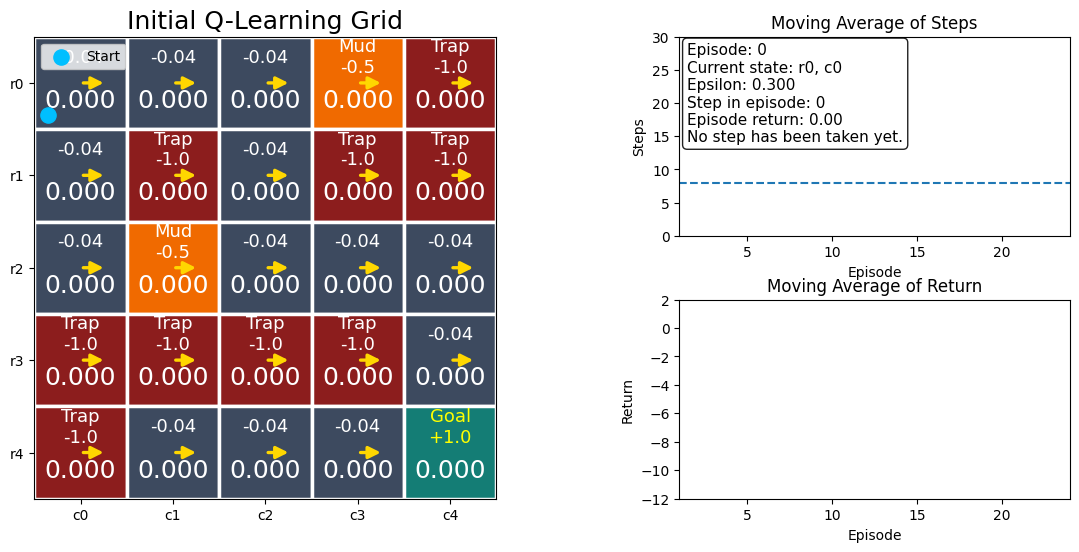

In [5]:

demo.render(title="Initial Q-Learning Grid")



## 3. Inspect one state before learning starts

Here we look at state `(0,0)` before any learning happens.

Notice:
- all four Q-values are tied at `0`
- the displayed arrow is only a **visual tie-break**
- this is why early behavior is unstable and exploratory


In [6]:

demo.inspect_state((0, 0))


State r0, c0
Greedy action right now: UP ↑ with Q = 0.0000


,action,arrow,q_value,next_state,reward,hit_wall
0,UP,↑,0.0,"(0, 0)",-0.10,True
1,DOWN,↓,0.0,"(1, 0)",-0.04,False
2,LEFT,←,0.0,"(0, 0)",-0.10,True
3,RIGHT,→,0.0,"(0, 1)",-0.04,False



## 4. Start Episode 1

This matches the beginning of the video:
- episode = 1
- epsilon = 0.30
- max_steps = 30


Started episode 1 | epsilon = 0.300 | max_steps = 30 | final_demo = False


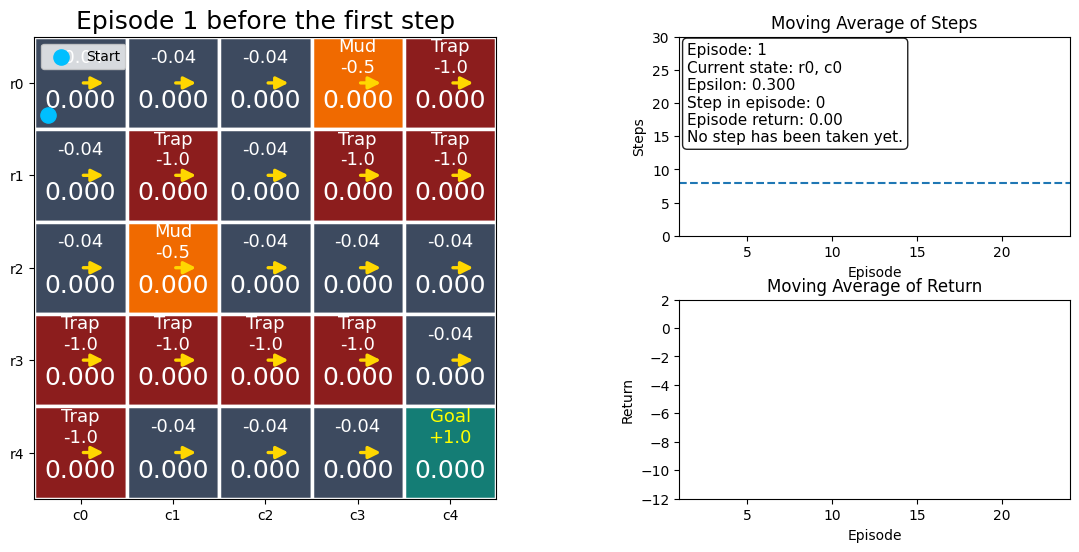

In [12]:

demo.begin_episode(episode=1, max_steps=30, epsilon=0.30, final_demo=False)
demo.render(title="Episode 1 before the first step")



## 5. Take exactly one Q-learning step

This is the most important cell in the notebook.

When you run it, you will see:
- the chosen action
- whether it was **explore** or **exploit**
- the reward
- the old Q-value
- the target
- the TD error
- the new Q-value
- the updated grid

Run this cell **again and again** if you want to continue the same episode one step at a time.


Ep 1 | step 12: r0, c2 --RIGHT--> r0, c3 | reward = -0.50 | explore
Q update: old = -0.2500, target = -0.5000, td_error = -0.2500, new = -0.3750


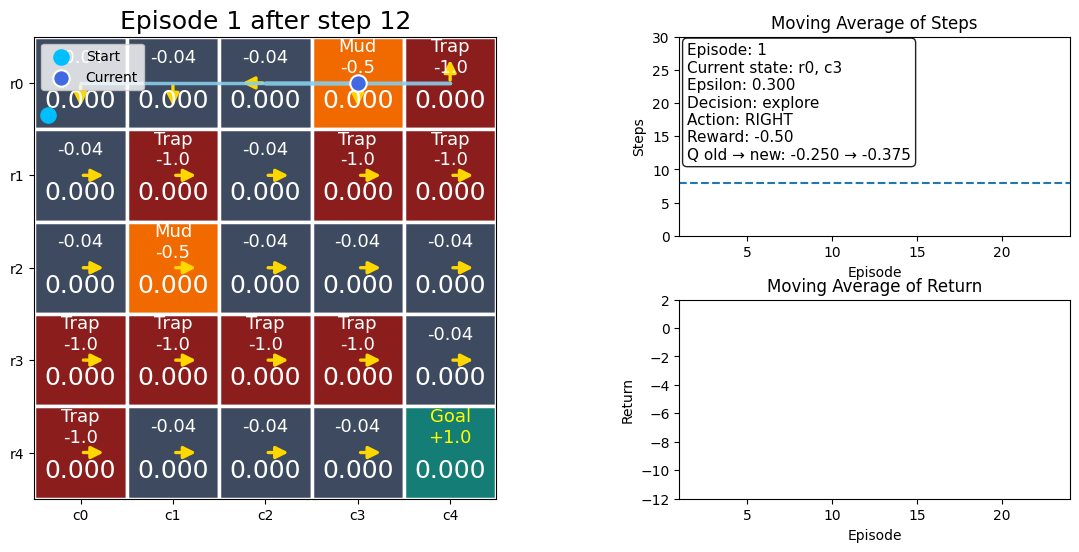

,episode,step,state,greedy_action,action_idx,action,decision,next_state,reward,hit_wall,reached_goal,old_q,target,td_error,new_q,episode_return_so_far,done,termination_reason
0,1,12,"(0, 2)",LEFT,3,RIGHT,explore,"(0, 3)",-0.5,False,False,-0.25,-0.5,-0.25,-0.375,-3.12,False,None


In [24]:

step_info = demo.step_and_render()
step_info



### Try this after a few steps

Use these helper views to understand what changed.


In [25]:

demo.show_status()


,episode,step_in_episode,current_state,epsilon,episode_return,in_episode,done,final_demo
0,1,12,"(0, 3)",0.3,-3.12,True,False,False


In [26]:

demo.values_table()


,c0,c1,c2,c3,c4
r0,0.0,0.0,0.0,0.0,0.0
r1,0.0,0.0,0.0,0.0,0.0
r2,0.0,0.0,0.0,0.0,0.0
r3,0.0,0.0,0.0,0.0,0.0
r4,0.0,0.0,0.0,0.0,0.0


In [27]:

demo.policy_table()


,c0,c1,c2,c3,c4
r0,↓,↓,←,↓,↑
r1,→,→,→,→,→
r2,→,→,→,→,→
r3,→,→,→,→,→
r4,→,→,→,→,GOAL


In [28]:

demo.recent_step_log(5)


,episode,step,state,greedy_action,action_idx,action,decision,next_state,reward,hit_wall,reached_goal,old_q,target,td_error,new_q,episode_return_so_far,done,termination_reason
0,1,8,"(0, 3)",UP,0,UP,exploit,"(0, 3)",-0.10,True,False,0.00,-0.10,-0.10,-0.050,-2.38,False,None
1,1,9,"(0, 3)",LEFT,2,LEFT,exploit,"(0, 2)",-0.04,False,False,0.00,-0.04,-0.04,-0.020,-2.42,False,None
2,1,10,"(0, 2)",UP,0,UP,exploit,"(0, 2)",-0.10,True,False,0.00,-0.10,-0.10,-0.050,-2.52,False,None
3,1,11,"(0, 2)",LEFT,0,UP,explore,"(0, 2)",-0.10,True,False,-0.05,-0.10,-0.05,-0.075,-2.62,False,None
4,1,12,"(0, 2)",LEFT,3,RIGHT,explore,"(0, 3)",-0.50,False,False,-0.25,-0.50,-0.25,-0.375,-3.12,False,None



## 6. Finish the current episode automatically

If you already took a few manual steps, this cell will continue **from the current state** until the episode ends.


In [29]:

ep1_log = demo.run_episode()
ep1_log.tail()


Episode 1 finished in 30 step(s) with return -11.70.


,episode,step,state,greedy_action,action_idx,action,decision,next_state,reward,hit_wall,reached_goal,old_q,target,td_error,new_q,episode_return_so_far,done,termination_reason
13,1,26,"(1, 4)",LEFT,2,LEFT,exploit,"(1, 3)",-1.00,False,False,0.0,-1.00,-1.00,-0.50,-10.58,False,None
14,1,27,"(1, 3)",DOWN,1,DOWN,exploit,"(2, 3)",-0.04,False,False,0.0,-0.04,-0.04,-0.02,-10.62,False,None
15,1,28,"(2, 3)",LEFT,2,LEFT,exploit,"(2, 2)",-0.04,False,False,0.0,-0.04,-0.04,-0.02,-10.66,False,None
16,1,29,"(2, 2)",RIGHT,3,RIGHT,exploit,"(2, 3)",-0.04,False,False,0.0,-0.04,-0.04,-0.02,-10.70,False,None
17,1,30,"(2, 3)",DOWN,1,DOWN,exploit,"(3, 3)",-1.00,False,False,0.0,-1.00,-1.00,-0.50,-11.70,True,max_steps


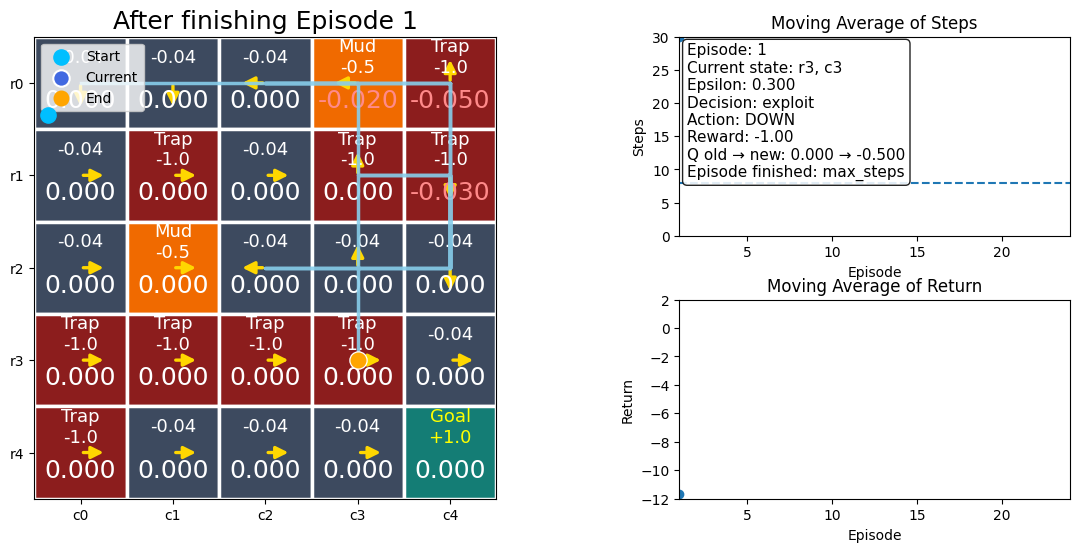

In [31]:

demo.render(title="After finishing Episode 1")



## 7. Inspect the updated Q-values of one state

Now state `(0,0)` may no longer have equal Q-values.

Look for:
- one action becoming better than the others
- a negative value for actions that led to bad outcomes


In [32]:

demo.inspect_state((0, 0))


State r0, c0
Greedy action right now: UP ↑ with Q = 0.0000


,action,arrow,q_value,next_state,reward,hit_wall
0,UP,↑,0.00,"(0, 0)",-0.10,True
1,DOWN,↓,0.00,"(1, 0)",-0.04,False
2,LEFT,←,0.00,"(0, 0)",-0.10,True
3,RIGHT,→,-0.02,"(0, 1)",-0.04,False



## 8. Replay the full **visual part** of the video from scratch

This creates a **new object** so your earlier manual work stays untouched.

It runs episodes 1–5 with the same schedule as the animation:
- episode 1 to 5
- max 30 steps each
- epsilon decays by `×0.85`


In [33]:

visual_demo = QLearningExplorer(alpha=0.5, gamma=0.9, epsilon=0.3, seed=42)
visual_summary = visual_demo.run_visual_schedule()
visual_summary


Reset complete. Seed = 42. Q-table is all zeros.
Started episode 1 | epsilon = 0.300 | max_steps = 30 | final_demo = False
Episode 1 finished in 30 step(s) with return -9.34.
Started episode 2 | epsilon = 0.255 | max_steps = 30 | final_demo = False
Episode 2 finished in 30 step(s) with return -8.52.
Started episode 3 | epsilon = 0.217 | max_steps = 30 | final_demo = False
Episode 3 finished in 16 step(s) with return -4.98.
Started episode 4 | epsilon = 0.184 | max_steps = 30 | final_demo = False
Episode 4 finished in 30 step(s) with return -6.24.
Started episode 5 | epsilon = 0.157 | max_steps = 30 | final_demo = False
Episode 5 finished in 30 step(s) with return -4.14.


,episode,steps,return,epsilon_used
0,1,30,-9.34,0.3000
1,2,30,-8.52,0.2550
2,3,16,-4.98,0.2167
3,4,30,-6.24,0.1842
4,5,30,-4.14,0.1566


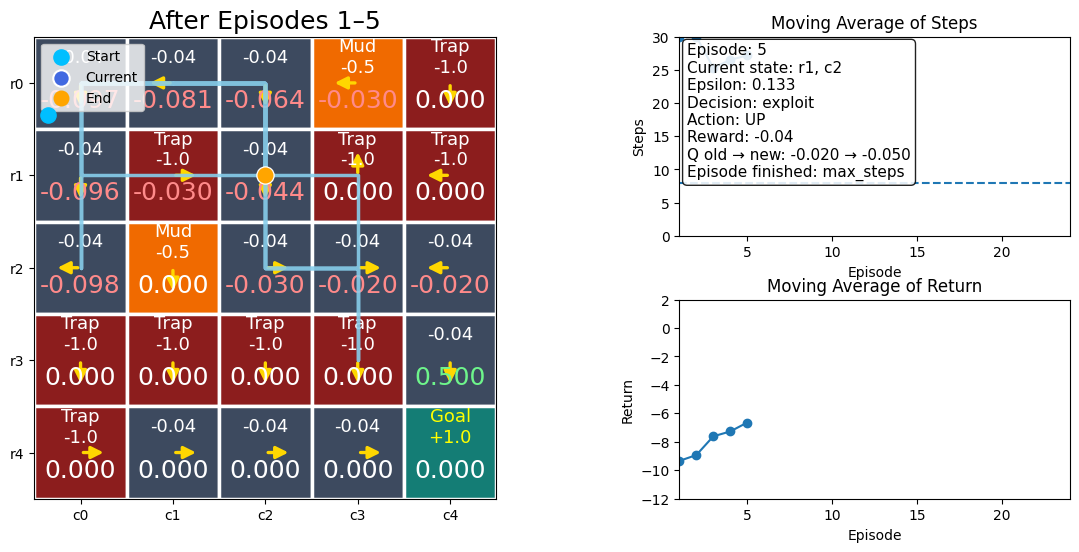

In [38]:

visual_demo.render(title="After Episodes 1–5")



## 9. Run the fast backend training (episodes 6–24)

This continues from the result of episodes 1–5.
It uses:
- `epsilon = 0.05`
- `max_steps = 50`

The charts on the right should become much cleaner after this stage.


In [39]:

backend_summary = visual_demo.run_backend_schedule()
backend_summary.tail()


Started episode 6 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Episode 6 finished in 20 step(s) with return -0.00.
Started episode 7 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Episode 7 finished in 24 step(s) with return -1.46.
Started episode 8 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Episode 8 finished in 14 step(s) with return 0.48.
Started episode 9 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Episode 9 finished in 17 step(s) with return 0.30.
Started episode 10 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Episode 10 finished in 19 step(s) with return 0.10.
Started episode 11 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Episode 11 finished in 8 step(s) with return -0.24.
Started episode 12 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Episode 12 finished in 12 step(s) with return 0.56.
Started episode 13 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Episode 13 finished in 8 step(s) with retu

,episode,steps,return
14,20,8,0.72
15,21,8,0.72
16,22,8,0.72
17,23,8,0.72
18,24,8,0.72


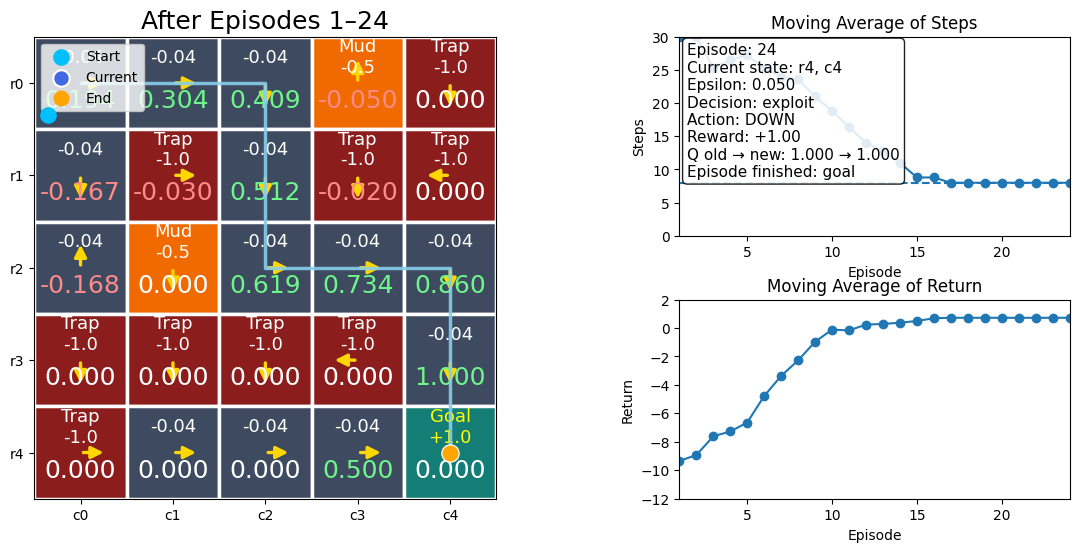

In [40]:

visual_demo.render(title="After Episodes 1–24")



## 10. Final greedy demo (Episode 25)

This is the same idea as the last green path in the video:
- no exploration
- no learning
- just follow the greedy policy


In [41]:

final_demo_log = visual_demo.run_final_demo(max_steps=12)
final_demo_log


Started episode 25 | epsilon = 0.000 | max_steps = 12 | final_demo = True
Final greedy demo ended after 8 step(s). Termination: goal.


,episode,step,state,greedy_action,action_idx,action,decision,next_state,reward,hit_wall,reached_goal,old_q,target,td_error,new_q,episode_return_so_far,done,termination_reason
0,25,1,"(0, 0)",RIGHT,3,RIGHT,exploit,"(0, 1)",-0.04,False,False,0.1943,0.2335,0.0392,0.1943,-0.04,False,None
1,25,2,"(0, 1)",RIGHT,3,RIGHT,exploit,"(0, 2)",-0.04,False,False,0.3039,0.3282,0.0243,0.3039,-0.08,False,None
2,25,3,"(0, 2)",DOWN,1,DOWN,exploit,"(1, 2)",-0.04,False,False,0.4092,0.4212,0.0121,0.4092,-0.12,False,None
3,25,4,"(1, 2)",DOWN,1,DOWN,exploit,"(2, 2)",-0.04,False,False,0.5125,0.5171,0.0046,0.5125,-0.16,False,None
4,25,5,"(2, 2)",RIGHT,3,RIGHT,exploit,"(2, 3)",-0.04,False,False,0.6190,0.6203,0.0013,0.6190,-0.20,False,None
5,25,6,"(2, 3)",RIGHT,3,RIGHT,exploit,"(2, 4)",-0.04,False,False,0.7337,0.7340,0.0003,0.7337,-0.24,False,None
6,25,7,"(2, 4)",DOWN,1,DOWN,exploit,"(3, 4)",-0.04,False,False,0.8600,0.8600,0.0000,0.8600,-0.28,False,None
7,25,8,"(3, 4)",DOWN,1,DOWN,exploit,"(4, 4)",1.00,False,True,1.0000,1.0000,0.0000,1.0000,0.72,True,goal


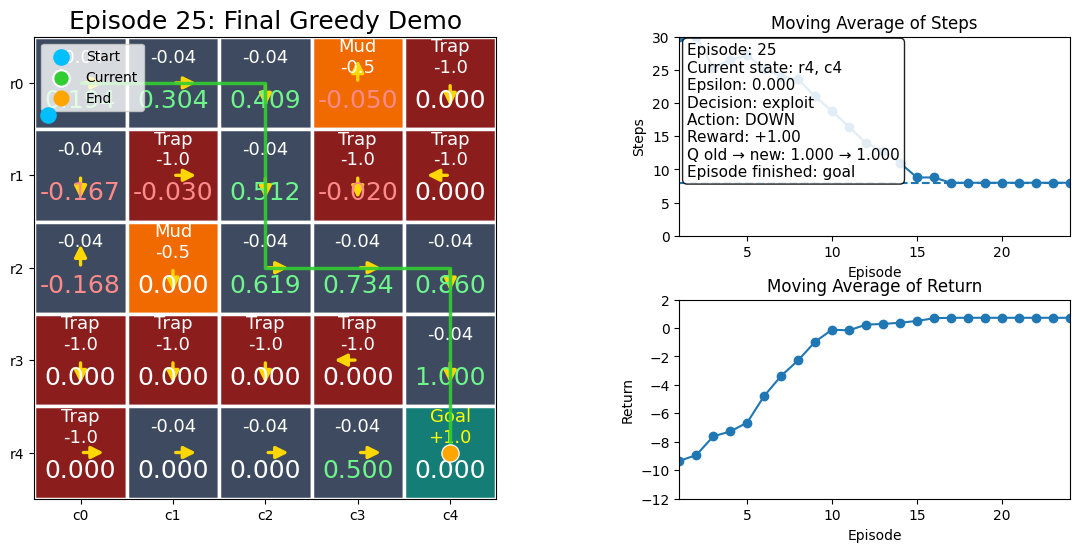

In [42]:

visual_demo.render(title="Episode 25: Final Greedy Demo")



## 11. Check the learned value view and policy view

These tables are often easier to read than the plotted grid.


In [43]:

visual_demo.values_table()


,c0,c1,c2,c3,c4
r0,0.194,0.304,0.409,-0.050,0.00
r1,-0.167,-0.030,0.512,-0.020,0.00
r2,-0.168,0.000,0.619,0.734,0.86
r3,0.000,0.000,0.000,0.000,1.00
r4,0.000,0.000,0.000,0.500,0.00


In [44]:

visual_demo.policy_table()


,c0,c1,c2,c3,c4
r0,→,→,↓,↑,↓
r1,↓,→,↓,↓,←
r2,↑,↓,→,→,↓
r3,↓,↓,↓,←,↓
r4,→,→,→,→,GOAL


In [45]:

visual_demo.episode_summary_table().tail(10)


,episode,steps,return,epsilon
14,15,8,0.72,0.05
15,16,8,0.72,0.05
16,17,8,0.72,0.05
17,18,8,0.72,0.05
18,19,8,0.72,0.05
19,20,8,0.72,0.05
20,21,8,0.72,0.05
21,22,8,0.72,0.05
22,23,8,0.72,0.05
23,24,8,0.72,0.05



## 12. Inspect a specific state in detail

This is a great way to explain **why** an arrow points in a certain direction.
Try different states such as:
- `(0,0)`
- `(0,2)`
- `(2,2)`
- `(3,4)`


In [46]:

visual_demo.inspect_state((0, 0))


State r0, c0
Greedy action right now: RIGHT → with Q = 0.1943


,action,arrow,q_value,next_state,reward,hit_wall
0,RIGHT,→,0.1943,"(0, 1)",-0.04,False
1,DOWN,↓,-0.1664,"(1, 0)",-0.04,False
2,LEFT,←,-0.1781,"(0, 0)",-0.10,True
3,UP,↑,-0.1855,"(0, 0)",-0.10,True


In [47]:

visual_demo.inspect_state((2, 2))


State r2, c2
Greedy action right now: RIGHT → with Q = 0.6190


,action,arrow,q_value,next_state,reward,hit_wall
0,RIGHT,→,0.6190,"(2, 3)",-0.04,False
1,UP,↑,-0.0785,"(1, 2)",-0.04,False
2,LEFT,←,-0.2500,"(2, 1)",-0.50,False
3,DOWN,↓,-0.7500,"(3, 2)",-1.00,False



## 13. One-cell worksheet idea

Use the next cell as a mini reflection task.

Before running it, answer these questions in your own words:

1. Which action is currently greedy at `(0,0)`?  
2. Why is that action better than the others?  
3. Which actions are punished by walls or bad rewards?  
4. Why does Q-learning not need the full environment model?

Then run the code and compare your answer.


In [48]:

state = (0, 0)
worksheet_df = visual_demo.inspect_state(state)
worksheet_df


State r0, c0
Greedy action right now: RIGHT → with Q = 0.1943


,action,arrow,q_value,next_state,reward,hit_wall
0,RIGHT,→,0.1943,"(0, 1)",-0.04,False
1,DOWN,↓,-0.1664,"(1, 0)",-0.04,False
2,LEFT,←,-0.1781,"(0, 0)",-0.10,True
3,UP,↑,-0.1855,"(0, 0)",-0.10,True



## 14. Reset and try your own experiment

You can change:
- `alpha`
- `gamma`
- `epsilon`
- `seed`

Then rerun training and compare what changes.

Example questions:
- What happens if exploration is smaller?
- What happens if `gamma` is smaller?
- Does the final path still reach the goal?


Reset complete. Seed = 42. Q-table is all zeros.
Started episode 1 | epsilon = 0.200 | max_steps = 30 | final_demo = False
Episode 1 finished in 26 step(s) with return -6.08.
Started episode 2 | epsilon = 0.170 | max_steps = 30 | final_demo = False
Episode 2 finished in 20 step(s) with return -7.06.
Started episode 3 | epsilon = 0.145 | max_steps = 30 | final_demo = False
Episode 3 finished in 30 step(s) with return -6.26.
Started episode 4 | epsilon = 0.123 | max_steps = 30 | final_demo = False
Episode 4 finished in 12 step(s) with return -0.86.
Started episode 5 | epsilon = 0.104 | max_steps = 30 | final_demo = False
Episode 5 finished in 24 step(s) with return -2.92.
Started episode 6 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Episode 6 finished in 45 step(s) with return -5.70.
Started episode 7 | epsilon = 0.050 | max_steps = 50 | final_demo = False
Episode 7 finished in 25 step(s) with return -0.26.
Started episode 8 | epsilon = 0.050 | max_steps = 50 | final_demo = F

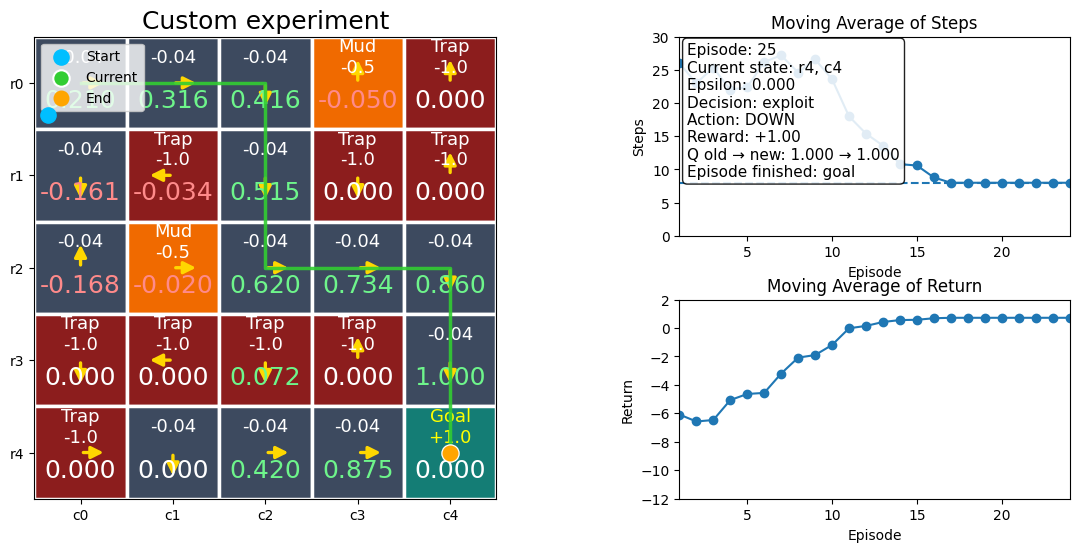

In [49]:

my_demo = QLearningExplorer(alpha=0.5, gamma=0.9, epsilon=0.2, seed=42)
my_demo.run_visual_schedule()
my_demo.run_backend_schedule()
my_demo.run_final_demo()
my_demo.render(title="Custom experiment")
